# Analysis of the LAC results

# First analysis: Are the prediction sets leaning to the correct veracity label

In [1]:
import pandas as pd
import ast

true_side_labels = {"true", "mostly-true", "half-true"}
false_side_labels = {"mostly-false", "false", "pants-fire"}

def verdict_side(verdict):
    if verdict in true_side_labels:
        return "true"
    if verdict in false_side_labels:
        return "false"
    return "unknown"

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def prediction_set_side(prediction_set):
    labels = parse_prediction_set(prediction_set)
    true_count = sum(label in true_side_labels for label in labels)
    false_count = sum(label in false_side_labels for label in labels)

    if true_count > false_count:
        return "true"
    if false_count > true_count:
        return "false"
    return "neutral"

def check_prediction_set(df):
    df["true_side"] = df["true_verdict"].apply(verdict_side)
    df["prediction_side"] = df["prediction_set"].apply(prediction_set_side)

    df["side_matches"] = df["prediction_side"] == df["true_side"]
    df["is_neutral"] = df["prediction_side"] == "neutral"

    total_rows = len(df)
    match_rate_all = df["side_matches"].mean()
    neutral_rate = df["is_neutral"].mean()

    non_neutral = df[~df["is_neutral"]]
    match_rate_non_neutral = non_neutral["side_matches"].mean() if len(non_neutral) else float("nan")

    print(f"Rows: {total_rows}")
    print(f"Prediction sets leaning to the correct side: {df['side_matches'].sum()} / {total_rows}")
    print(f"Match rate including neutral sets: {match_rate_all:.3f}")
    print(f"Neutral rate: {neutral_rate:.3f}")
    print(f"Match rate excluding neutral sets: {match_rate_non_neutral:.3f}")

    # Optional: show a few examples
    df[["true_verdict", "prediction_set", "true_side", "prediction_side", "side_matches"]].head(10)

## Gather the results for no evidence and evidence 

### Show for each category how are the prediction sets leaning to 

In [2]:
# Compare the results side by side for each category, to see if evidence improves the alignment of prediction sets with the true verdict sides.

no_evidence_csv = {
    'crime': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/crime/conformal_results_all_trials_100trials_20260327_141313.csv",
    'economy': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/economy/conformal_results_all_trials_100trials_20260327_153533.csv",
    'education': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/education/conformal_results_all_trials_100trials_20260327_143823.csv",
    'elections': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/elections/conformal_results_all_trials_100trials_20260327_153731.csv",
    'health-care': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/health-care/conformal_results_all_trials_100trials_20260327_155654.csv",
    'immigration': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/immigration/conformal_results_all_trials_100trials_20260327_144131.csv",
    'jobs': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/jobs/conformal_results_all_trials_100trials_20260327_142840.csv",
    'taxes': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/taxes/conformal_results_all_trials_100trials_20260327_151637.csv"
}

with_evidence_csv = {
    'crime': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/crime/conformal_results_all_trials_100trials_20260407_071658.csv",
    'economy': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/economy/conformal_results_all_trials_100trials_20260407_140549.csv",
    'education': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/education/conformal_results_all_trials_100trials_20260407_102821.csv",
    'elections': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/elections/conformal_results_all_trials_100trials_20260407_134947.csv",
    'health-care': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/health-care/conformal_results_all_trials_100trials_20260407_163030.csv",
    'immigration': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/immigration/conformal_results_all_trials_100trials_20260407_102713.csv",
    'jobs': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/jobs/conformal_results_all_trials_100trials_20260407_084803.csv",
    'taxes': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/taxes/conformal_results_all_trials_100trials_20260407_122809.csv"
}


for category in no_evidence_csv.keys():
    print(f"Category: {category}")
    print("Without evidence:")
    df_no_evidence = pd.read_csv(no_evidence_csv[category])
    check_prediction_set(df_no_evidence)
    
    print("\nWith evidence:")
    df_with_evidence = pd.read_csv(with_evidence_csv[category])
    check_prediction_set(df_with_evidence)
    
    print("\n" + "="*50 + "\n")

Category: crime
Without evidence:
Rows: 55000
Prediction sets leaning to the correct side: 31578 / 55000
Match rate including neutral sets: 0.574
Neutral rate: 0.188
Match rate excluding neutral sets: 0.707

With evidence:
Rows: 55000
Prediction sets leaning to the correct side: 43911 / 55000
Match rate including neutral sets: 0.798
Neutral rate: 0.135
Match rate excluding neutral sets: 0.923


Category: economy
Without evidence:
Rows: 97800
Prediction sets leaning to the correct side: 55353 / 97800
Match rate including neutral sets: 0.566
Neutral rate: 0.187
Match rate excluding neutral sets: 0.696

With evidence:
Rows: 97800
Prediction sets leaning to the correct side: 77250 / 97800
Match rate including neutral sets: 0.790
Neutral rate: 0.118
Match rate excluding neutral sets: 0.896


Category: education
Without evidence:
Rows: 67600
Prediction sets leaning to the correct side: 36637 / 67600
Match rate including neutral sets: 0.542
Neutral rate: 0.176
Match rate excluding neutral set

In [3]:
"""
Visualize prediction-set evaluation results with and without evidence.

Produces four charts:
  1. Dumbbell chart       - lift from evidence per category
  2. 100% stacked bars    - correct / neutral / incorrect breakdown
  3. Scatter vs. y=x      - with-evidence vs. without-evidence accuracy
  4. Grouped bar chart    - simple side-by-side accuracy comparison
"""

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------------------------
# Data (paste your numbers here, or compute them from your DataFrame)
# ---------------------------------------------------------------------------
results = {
    "crime":       {"without": (0.574, 0.188), "with": (0.798, 0.135)},
    "economy":     {"without": (0.566, 0.187), "with": (0.790, 0.118)},
    "education":   {"without": (0.542, 0.176), "with": (0.739, 0.159)},
    "elections":   {"without": (0.628, 0.163), "with": (0.832, 0.096)},
    "health-care": {"without": (0.543, 0.182), "with": (0.796, 0.127)},
    "immigration": {"without": (0.600, 0.140), "with": (0.767, 0.139)},
    "jobs":        {"without": (0.576, 0.151), "with": (0.781, 0.126)},
    "taxes":       {"without": (0.521, 0.200), "with": (0.790, 0.119)},
}

# Sort by size of lift (with - without) for a tidier dumbbell chart
categories = sorted(results.keys(),
                    key=lambda c: results[c]["with"][0] - results[c]["without"][0])

without_correct = np.array([results[c]["without"][0] for c in categories])
with_correct    = np.array([results[c]["with"][0]    for c in categories])
without_neutral = np.array([results[c]["without"][1] for c in categories])
with_neutral    = np.array([results[c]["with"][1]    for c in categories])
without_wrong   = 1 - without_correct - without_neutral
with_wrong      = 1 - with_correct - with_neutral

# Color palette
C_WITHOUT = "#d97757"   # warm orange
C_WITH    = "#3a7d7b"   # teal
C_CORRECT = "#3a7d7b"
C_NEUTRAL = "#c8c2b6"
C_WRONG   = "#d97757"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titleweight":  "bold",
    "axes.titlesize":    13,
})


# ---------------------------------------------------------------------------
# 2. 100% stacked bar chart
# ---------------------------------------------------------------------------
def stacked_bar_chart(path):
    fig, ax = plt.subplots(figsize=(11, 7))
    x = np.arange(len(categories))
    width = 0.38

    # Without evidence (left bar of each pair) — hatched
    ax.bar(x - width / 2, without_correct, width,
           color=C_CORRECT, hatch="//", edgecolor="white")
    ax.bar(x - width / 2, without_neutral, width, bottom=without_correct,
           color=C_NEUTRAL, hatch="//", edgecolor="white")
    ax.bar(x - width / 2, without_wrong, width,
           bottom=without_correct + without_neutral,
           color=C_WRONG, hatch="//", edgecolor="white")

    # With evidence (right bar of each pair) — solid
    ax.bar(x + width / 2, with_correct, width,
           color=C_CORRECT, edgecolor="white")
    ax.bar(x + width / 2, with_neutral, width, bottom=with_correct,
           color=C_NEUTRAL, edgecolor="white")
    ax.bar(x + width / 2, with_wrong, width,
           bottom=with_correct + with_neutral,
           color=C_WRONG, edgecolor="white")

    # numeric labels on the "correct" (teal) segment
    for xi, v in zip(x - width / 2, without_correct):
        ax.text(xi, v / 2, f"{v:.2f}", ha="center", va="center",
                color="white", fontsize=8, fontweight="bold")
    for xi, v in zip(x + width / 2, with_correct):
        ax.text(xi, v / 2, f"{v:.2f}", ha="center", va="center",
                color="white", fontsize=8, fontweight="bold")

    # numeric labels on the "incorrect" (orange) segment
    for xi, v_bot, v_wrong in zip(x - width / 2,
                                   without_correct + without_neutral,
                                   without_wrong):
        mid = v_bot + v_wrong / 2
        ax.text(xi, mid, f"{v_wrong:.2f}", ha="center", va="center",
                color="white", fontsize=8, fontweight="bold")
    for xi, v_bot, v_wrong in zip(x + width / 2,
                                   with_correct + with_neutral,
                                   with_wrong):
        mid = v_bot + v_wrong / 2
        ax.text(xi, mid, f"{v_wrong:.2f}", ha="center", va="center",
                color="white", fontsize=8, fontweight="bold")

    # "no ev." / "ev." sub-labels under each bar pair
    for xi in x:
        ax.text(xi - width / 2, -0.025, "no ev.", ha="center", va="top",
                fontsize=7.5, color="#666")
        ax.text(xi + width / 2, -0.025, "ev.",    ha="center", va="top",
                fontsize=7.5, color="#666")

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.tick_params(axis="x", pad=18)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of prediction sets")

    # Title only at top
    fig.suptitle("Prediction outcome breakdown by category",
                 fontsize=14, fontweight="bold", y=0.97)

    # Two legends below the x-axis (moved lower)
    outcome_handles = [
        plt.Rectangle((0, 0), 1, 1, color=C_CORRECT, label="Correct"),
        plt.Rectangle((0, 0), 1, 1, color=C_NEUTRAL, label="Neutral"),
        plt.Rectangle((0, 0), 1, 1, color=C_WRONG,   label="Incorrect"),
    ]
    condition_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="#555",
                      hatch="//", label="Without evidence"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#555", edgecolor="#555",
                      label="With evidence"),
    ]
    leg1 = ax.legend(handles=outcome_handles, title="Outcome",
                     loc="upper center", bbox_to_anchor=(0.30, -0.16),
                     ncol=3, frameon=False)
    ax.add_artist(leg1)
    ax.legend(handles=condition_handles, title="Condition",
              loc="upper center", bbox_to_anchor=(0.78, -0.16),
              ncol=2, frameon=False)

    # Description slightly lower to sit closer to legends
    fig.text(
        0.5, 0.007,
        "We check whether each prediction set leans to the correct truth side (true vs. false).\n"
        "A prediction set leans 'correctly' when the majority of labels in the set are on the same truth side as the ground truth,\n"
        "'incorrectly' when the majority leans the opposite way, and 'neutral' when counts are tied.\n"
        "Left bar (hatched) = model WITHOUT evidence.   Right bar (solid) = model WITH evidence.",
        ha="center", va="top", fontsize=12.0, color="#444",
    )

    plt.tight_layout(rect=[0, 0.00, 1, 0.94])
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)


# ---------------------------------------------------------------------------
if __name__ == "__main__":

    stacked_bar_chart("stacked_bar.png")
    print("Saved: stacked_bar.png")

Saved: stacked_bar.png


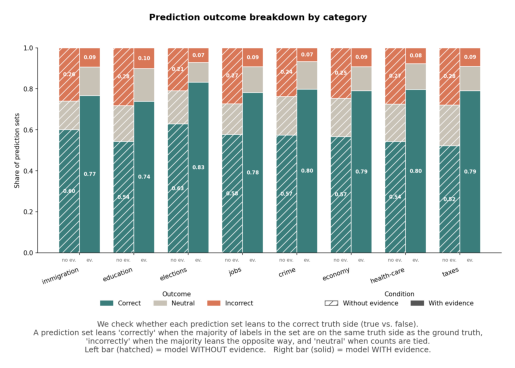

In [4]:
# Display the stacked bar

import matplotlib.pyplot as plt
img = plt.imread("stacked_bar.png")
plt.imshow(img); plt.axis("off"); plt.show()


# Conclusion from the first analysis:

### Without evidence, 21 to 28% of prediction sets lean toward the wrong truth side despite the 90% conformal coverage guarantee. With evidence, this drops to under 10% across all categories. This means that while conformal prediction ensures the true label is included in the set with high probability, the composition of the set without evidence is often misleading. A human fact-checker relying on the set's overall lean to guide a decision would be pointed in the wrong direction roughly a quarter of the time. Evidence reshapes the internal structure of the sets, not just their size, pushing them to concentrate on the correct side of the true/false boundary.

### It's also worth noting what happens to the neutral sets. Without evidence, around 14–20% of prediction sets are evenly split between the true and false sides, offering no directional signal at all. With evidence, this drops to roughly 10–16%, meaning fewer sets are ambiguous. Taken together, the share of sets that give a useful directional signal, leaning to the correct side, rises from roughly 52–63% without evidence to 74–83% with evidence, depending on the category.

# Second analysis: What are the distribution for each of the prediction set size (e.g., 1,2,3,4,5,6)?
### For each category, we will see the distribution of each prediction set sizes (how many are of size 1, 2, 3, 4, 5 and 6)

While not visible in the chart, the elections and immigration have 39 and 5 6-label prediction sets, and the rest have 0.

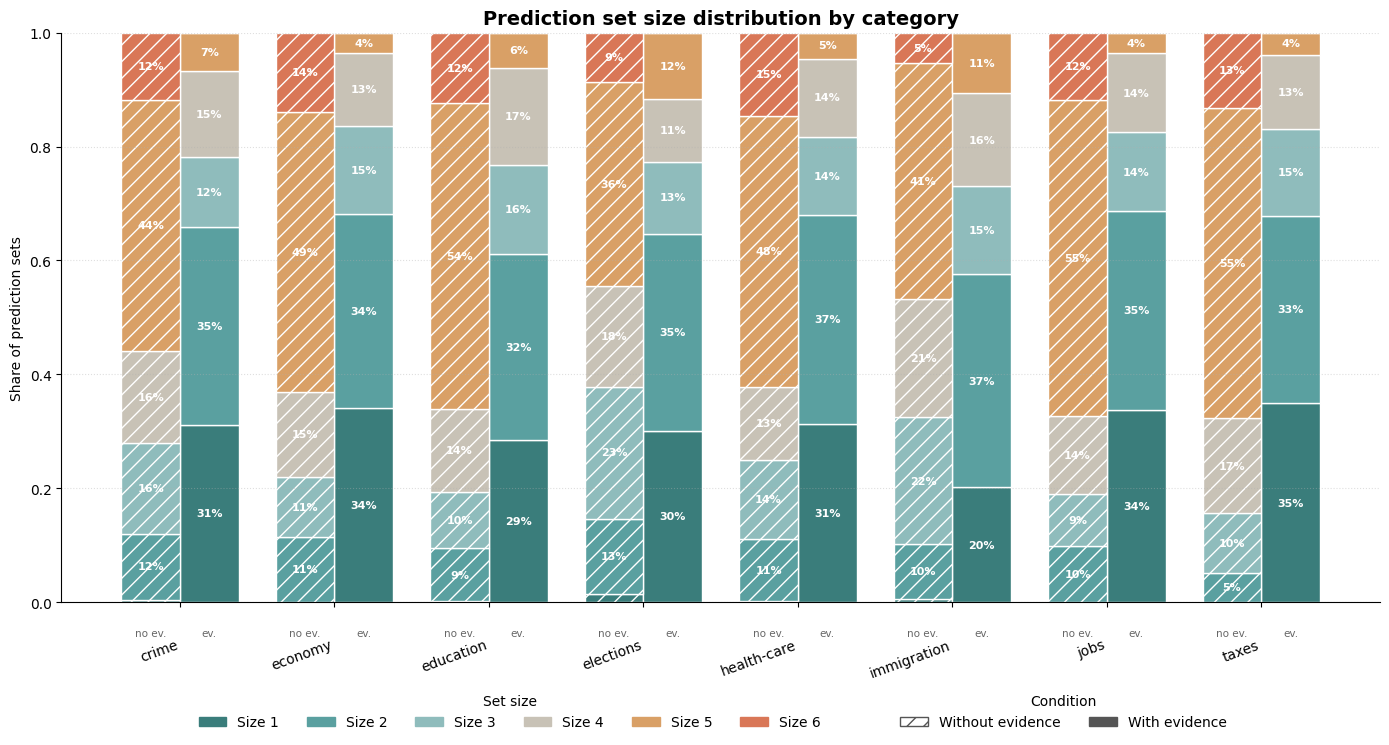

Saved: set_size_distribution.png


In [5]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def ensure_set_size(df):
    if "set_size" not in df.columns:
        df = df.copy()
        df["set_size"] = df["prediction_set"].apply(lambda x: len(parse_prediction_set(x)))
    return df

def get_size_percentages(csv_path):
    df = pd.read_csv(csv_path)
    df = ensure_set_size(df)
    counts = df["set_size"].value_counts().reindex([1, 2, 3, 4, 5, 6], fill_value=0)
    return counts / counts.sum()

def plot_all_categories_set_sizes(no_evidence_csv, with_evidence_csv, output_path="set_size_distribution.png"):
    categories = list(no_evidence_csv.keys())
    sizes = [1, 2, 3, 4, 5, 6]

    no_data = {cat: get_size_percentages(no_evidence_csv[cat]) for cat in categories}
    with_data = {cat: get_size_percentages(with_evidence_csv[cat]) for cat in categories}

    colors = ["#3a7d7b", "#5aa0a0", "#8fbcbc", "#c8c2b6", "#d9a066", "#d97757"]

    x = np.arange(len(categories))
    width = 0.38

    fig, ax = plt.subplots(figsize=(14, 8))

    for i, size in enumerate(sizes):
        no_bottom = np.array([sum(no_data[cat].iloc[:i]) for cat in categories])
        with_bottom = np.array([sum(with_data[cat].iloc[:i]) for cat in categories])

        no_vals = np.array([no_data[cat].iloc[i] for cat in categories])
        with_vals = np.array([with_data[cat].iloc[i] for cat in categories])

        ax.bar(
            x - width / 2,
            no_vals,
            width,
            bottom=no_bottom,
            color=colors[i],
            edgecolor="white",
            hatch="//",
        )
        ax.bar(
            x + width / 2,
            with_vals,
            width,
            bottom=with_bottom,
            color=colors[i],
            edgecolor="white",
        )

        for xi, bottom, val in zip(x - width / 2, no_bottom, no_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white",
                    fontweight="bold",
                )

        for xi, bottom, val in zip(x + width / 2, with_bottom, with_vals):
            if val >= 0.01:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white",
                    fontweight="bold",
                )

    for xi in x:
        ax.text(xi - width / 2, -0.045, "no ev.", ha="center", va="top", fontsize=7.5, color="#666")
        ax.text(xi + width / 2, -0.045, "ev.", ha="center", va="top", fontsize=7.5, color="#666")

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.tick_params(axis="x", pad=22)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of prediction sets")
    ax.set_title("Prediction set size distribution by category", fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    condition_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="#555", hatch="//", label="Without evidence"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#555", edgecolor="#555", label="With evidence"),
    ]
    size_handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors[i], label=f"Size {sizes[i]}")
        for i in range(len(sizes))
    ]

    leg1 = ax.legend(
        handles=size_handles,
        title="Set size",
        loc="upper center",
        bbox_to_anchor=(0.34, -0.14),
        ncol=6,
        frameon=False,
    )
    ax.add_artist(leg1)

    ax.legend(
        handles=condition_handles,
        title="Condition",
        loc="upper center",
        bbox_to_anchor=(0.76, -0.14),
        ncol=2,
        frameon=False,
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.24)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_all_categories_set_sizes(no_evidence_csv, with_evidence_csv)
print("Saved: set_size_distribution.png")

# Conclusion from the second analysis:

### Evidence makes prediction sets substantially smaller and more decisive. Without evidence, sets tend to spread across 4–6 labels, offering little practical guidance. With evidence, they concentrate heavily on sizes 1–2 across all categories, meaning the model commits to fewer labels with higher confidence. The effect is universal across topics, though some categories like education and health-care retain more residual uncertainty than others.

# Third analysis: What were the true label of the statements whose prediction set did not include it?

### Look for each of the failed prediction sets what should have them include

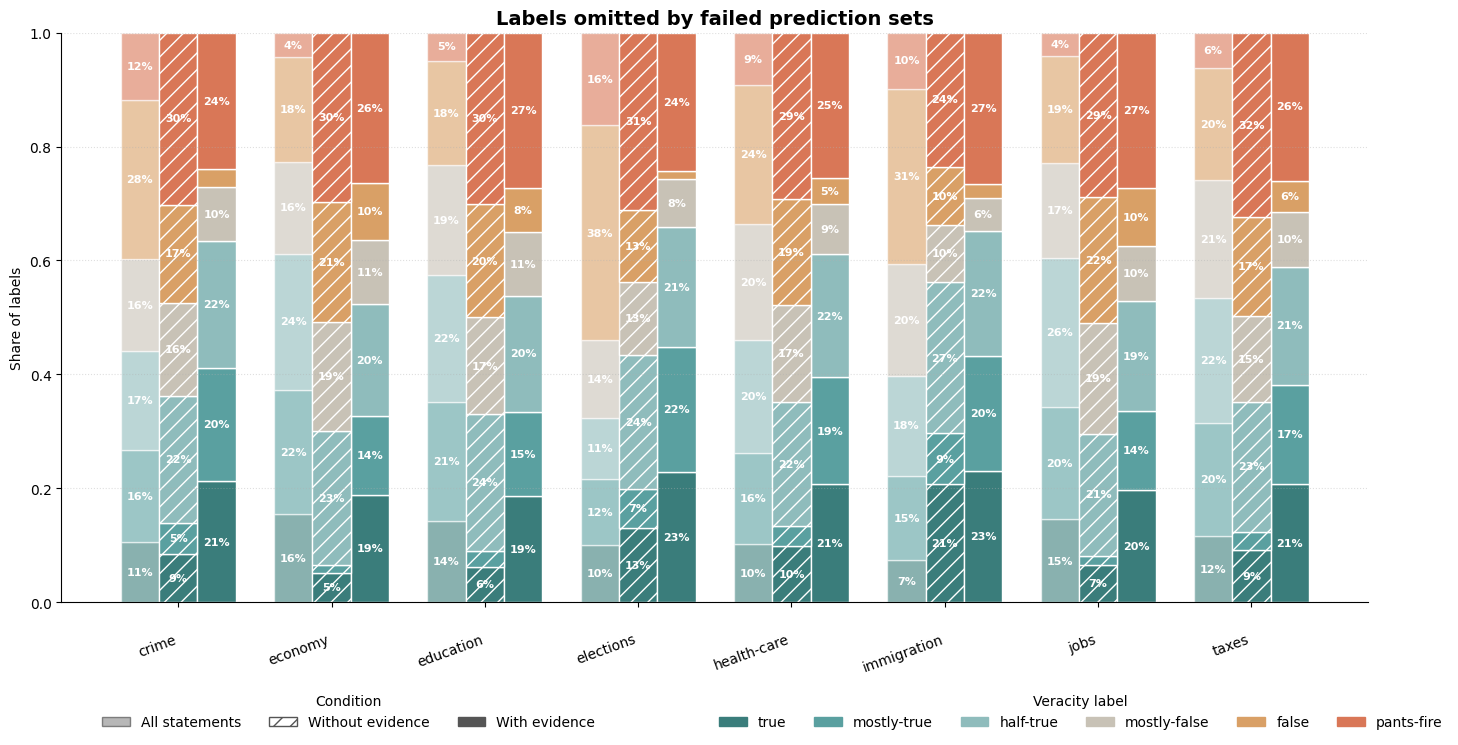

Saved: failed_set_omissions_by_category.png


In [23]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LABEL_ORDER = ["true", "mostly-true", "half-true", "mostly-false", "false", "pants-fire"]

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def get_failed_set_label_distribution(csv_path):
    df = pd.read_csv(csv_path)

    if "is_covered" not in df.columns:
        raise ValueError(f"{csv_path} does not contain an 'is_covered' column.")

    total_prediction_sets = len(df)
    failed_df = df[df["is_covered"] == False].copy()
    failed_df["prediction_set"] = failed_df["prediction_set"].apply(parse_prediction_set)

    omitted_counts = {label: 0 for label in LABEL_ORDER}
    total_omissions = 0

    for pred_set in failed_df["prediction_set"]:
        pred_set = set(pred_set)
        omitted_labels = [label for label in LABEL_ORDER if label not in pred_set]
        for label in omitted_labels:
            omitted_counts[label] += 1
            total_omissions += 1

    if total_omissions == 0:
        proportions = pd.Series({label: 0 for label in LABEL_ORDER})
    else:
        proportions = pd.Series(
            {label: omitted_counts[label] / total_omissions for label in LABEL_ORDER}
        )

    failed_rate = len(failed_df) / total_prediction_sets if total_prediction_sets else 0
    return proportions, len(failed_df), failed_rate

def get_all_statements_label_distribution(csv_path):
    df = pd.read_csv(csv_path)

    if "true_verdict" not in df.columns:
        raise ValueError(f"{csv_path} does not contain a 'true_verdict' column.")

    counts = df["true_verdict"].value_counts().reindex(LABEL_ORDER, fill_value=0)
    proportions = counts / counts.sum() if counts.sum() else counts
    return proportions, len(df)

def plot_failed_set_omissions(no_evidence_csv, with_evidence_csv, output_path="failed_set_omissions_by_category.png"):
    categories = list(no_evidence_csv.keys())

    label_colors = {
        "true": "#3a7d7b",
        "mostly-true": "#5aa0a0",
        "half-true": "#8fbcbc",
        "mostly-false": "#c8c2b6",
        "false": "#d9a066",
        "pants-fire": "#d97757",
    }

    no_data = {}
    with_data = {}
    all_data = {}
    no_failed_rates = {}
    with_failed_rates = {}

    for category in categories:
        no_props, no_failed, no_failed_rate = get_failed_set_label_distribution(no_evidence_csv[category])
        with_props, with_failed, with_failed_rate = get_failed_set_label_distribution(with_evidence_csv[category])
        all_props, total_count = get_all_statements_label_distribution(no_evidence_csv[category])

        no_data[category] = no_props
        with_data[category] = with_props
        all_data[category] = all_props
        no_failed_rates[category] = no_failed_rate
        with_failed_rates[category] = with_failed_rate

    x = np.arange(len(categories))
    width = 0.25

    fig, ax = plt.subplots(figsize=(15, 8))

    no_bottom = np.zeros(len(categories))
    with_bottom = np.zeros(len(categories))
    all_bottom = np.zeros(len(categories))

    for label in LABEL_ORDER:
        no_vals = np.array([no_data[cat][label] for cat in categories])
        with_vals = np.array([with_data[cat][label] for cat in categories])
        all_vals = np.array([all_data[cat][label] for cat in categories])

        ax.bar(
            x - width,
            all_vals,
            width,
            bottom=all_bottom,
            color=label_colors[label],
            edgecolor="white",
            alpha=0.6,
        )
        ax.bar(
            x,
            no_vals,
            width,
            bottom=no_bottom,
            color=label_colors[label],
            edgecolor="white",
            hatch="//",
        )
        ax.bar(
            x + width,
            with_vals,
            width,
            bottom=with_bottom,
            color=label_colors[label],
            edgecolor="white",
        )

        for xi, bottom, val in zip(x - width, all_bottom, all_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white",
                    fontweight="bold",
                )

        for xi, bottom, val in zip(x, no_bottom, no_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white",
                    fontweight="bold",
                )

        for xi, bottom, val in zip(x + width, with_bottom, with_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white",
                    fontweight="bold",
                )

        all_bottom += all_vals
        no_bottom += no_vals
        with_bottom += with_vals

    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.tick_params(axis="x", pad=18)
    ax.set_ylabel("Share of labels")
    ax.set_title("Labels omitted by failed prediction sets", fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    condition_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor="#999", edgecolor="#555", alpha=0.7, label="All statements"),
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="#555", hatch="//", label="Without evidence"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#555", edgecolor="#555", label="With evidence"),
    ]
    label_handles = [
        plt.Rectangle((0, 0), 1, 1, color=label_colors[label], label=label)
        for label in LABEL_ORDER
    ]

    leg1 = ax.legend(
        handles=condition_handles,
        title="Condition",
        bbox_to_anchor=(0.22, -0.14),
        loc="upper center",
        ncol=3,
        frameon=False,
    )
    ax.add_artist(leg1)

    ax.legend(
        handles=label_handles,
        title="Veracity label",
        bbox_to_anchor=(0.78, -0.14),
        loc="upper center",
        ncol=6,
        frameon=False,
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.24)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_failed_set_omissions(no_evidence_csv, with_evidence_csv)
print("Saved: failed_set_omissions_by_category.png")